# Customer Segmentation using K-Means Clustering

## Project Overview

Customer segmentation is a technique used to divide customers into different groups based on their characteristics and purchasing behavior.

In this project, K-Means clustering algorithm is used to segment customers based on:
- Age
- Annual Income
- Spending Score

The objective is to identify different customer groups and help businesses create personalized marketing strategies.


In [ ]:
# Importing required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [ ]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


###EDA


## Gender Distribution

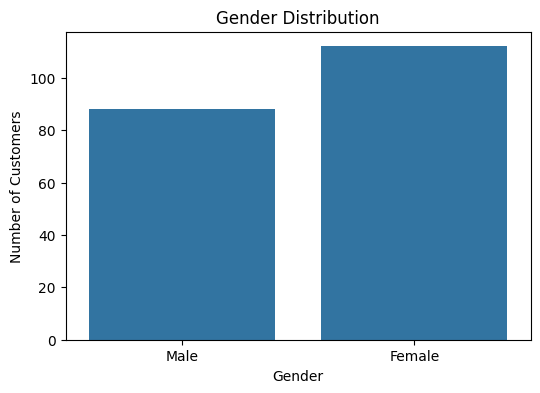

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Number of Customers")

plt.show()

### Observation

- The dataset contains both male and female customers.
- Female customers are slightly more than male customers.
- The gender distribution is fairly balanced, making the dataset suitable for customer segmentation without significant gender bias.

## Age Distribution

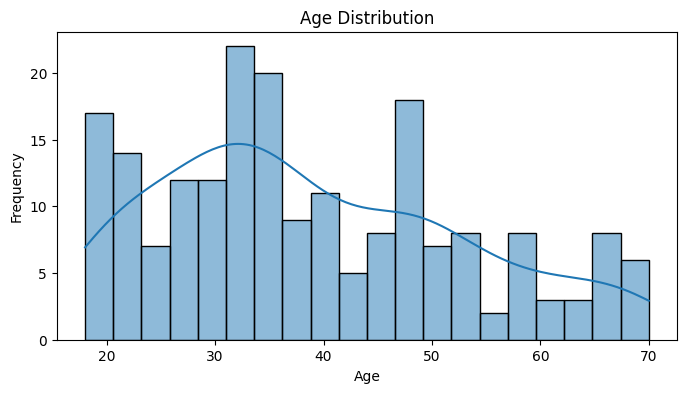

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

### Observation

- Customer ages range from 18 to 70 years.
- Most customers belong to the age group of approximately 25–40 years.
- The dataset contains customers from various age groups, making it suitable for analyzing purchasing behavior across different ages.

## Annual Income Distribution

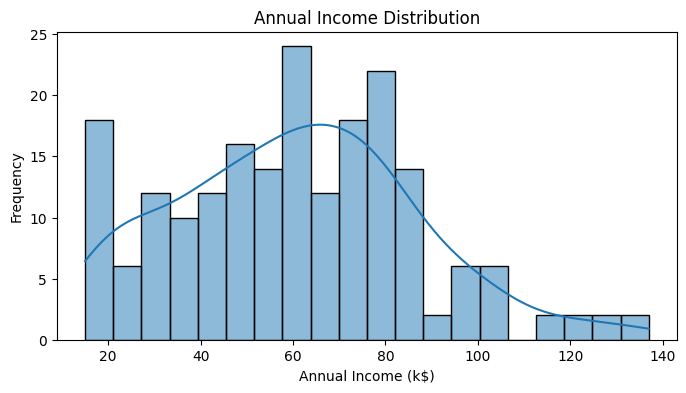

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    df['Annual Income (k$)'],
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")

plt.xlabel("Annual Income (k$)")

plt.ylabel("Frequency")

plt.show()

### Observation

- Annual income ranges from 15k$ to 137k$.
- Most customers have a medium annual income between 40k$ and 80k$.
- Only a small number of customers belong to the very high-income category.

## Spending Score Distribution

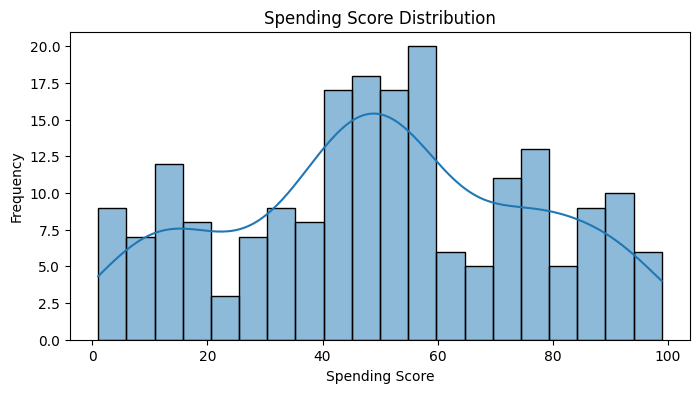

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(
    df['Spending Score (1-100)'],
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")

plt.xlabel("Spending Score")

plt.ylabel("Frequency")

plt.show()

### Observation

- Spending scores range from 1 to 99.
- Customers exhibit a wide variety of spending behaviors.
- Some customers spend very little, while others spend frequently, making this feature highly useful for customer segmentation.

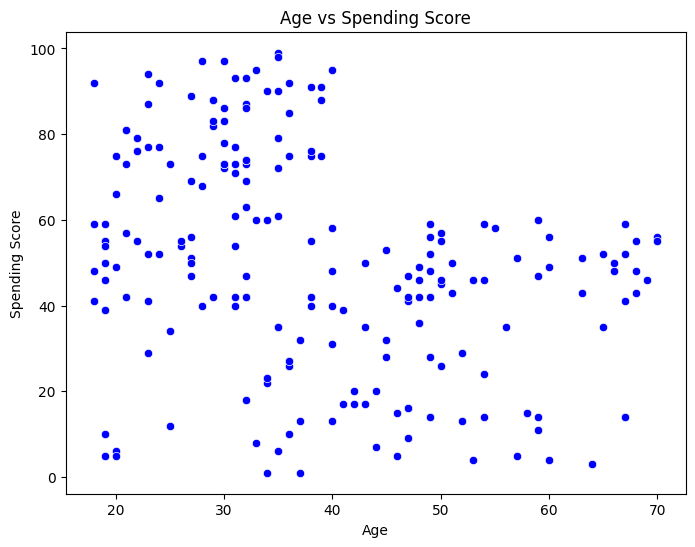

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Age',
    y='Spending Score (1-100)',
    data=df,
    color='blue'
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

### Observation

- Younger customers generally tend to have higher spending scores.
- Older customers show comparatively lower spending scores.
- This suggests that age may influence customer purchasing behavior.

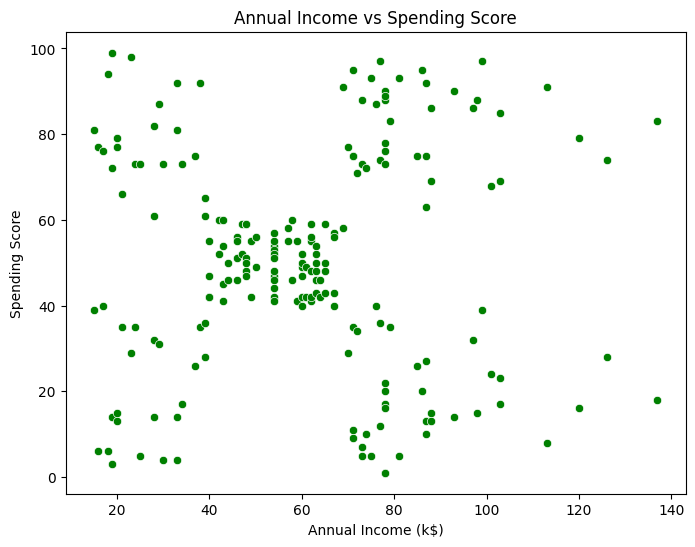

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df,
    color='green'
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

### Observation

- Customers with similar income levels have different spending habits.
- Some high-income customers spend a lot, while others spend very little.
- This variation indicates that customer segmentation can help identify different purchasing patterns.

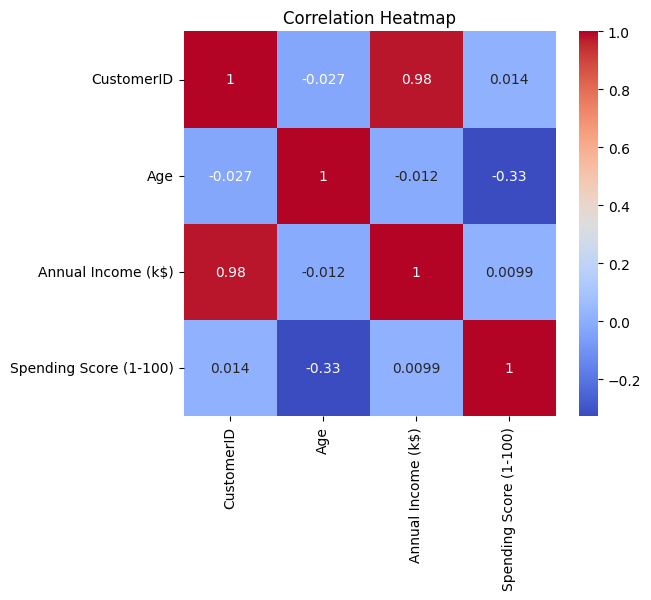

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Most numerical features show weak correlations.
- This indicates that each feature contributes unique information.
- Therefore, using multiple features together for clustering is beneficial.

In [ ]:
# Removing CustomerID column

df.drop('CustomerID', axis=1, inplace=True)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## Data Preprocessing

The `CustomerID` column is removed because it is only a unique identifier and does not contribute to customer behavior or clustering.

In [ ]:
df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


### Encoding Categorical Data

The `Gender` column is converted into numerical values using label encoding:

- Male → 0
- Female → 1

This conversion is necessary because machine learning algorithms work with numerical data.

In [ ]:
X = df

X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


## Feature Selection

The following features are selected for clustering:

- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)

These features represent customer demographics and purchasing behavior.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [ 0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [ 0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [ 0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [ 0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [ 0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [-1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [ 0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [-1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [ 0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [ 0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [ 0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [-1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [-1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [ 0.88640526, -0.

## Feature Scaling

The selected features have different ranges.

StandardScaler is applied to standardize the data so that each feature contributes equally during distance calculations performed by the K-Means algorithm.

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

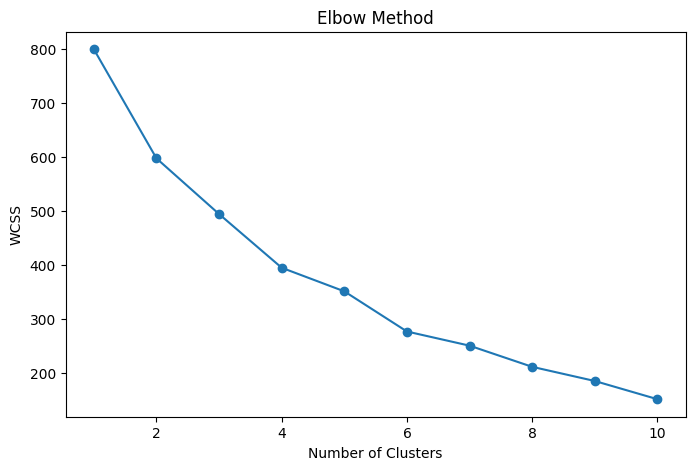

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

## Elbow Method

The Elbow Method is used to determine the optimal number of clusters.

The point where the WCSS curve begins to flatten is considered the optimal number of clusters.

For this dataset, the elbow point is expected around **5 clusters**.

# K-Means Clustering

K-Means clustering is applied using the optimal number of clusters obtained from the Elbow Method.

The algorithm groups customers into different segments based on similarities in their demographic and spending behavior.

In [ ]:
# Applying K-Means Clustering

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

clusters

array([2, 2, 4, 4, 4, 4, 4, 4, 0, 4, 0, 4, 0, 4, 0, 2, 4, 2, 0, 4, 2, 2,
       0, 2, 0, 2, 0, 2, 4, 4, 0, 4, 0, 2, 0, 4, 0, 4, 4, 4, 0, 2, 0, 4,
       0, 4, 0, 4, 4, 4, 0, 2, 4, 0, 0, 0, 0, 0, 4, 0, 0, 2, 0, 0, 0, 2,
       4, 0, 2, 4, 0, 0, 0, 0, 0, 2, 3, 2, 4, 0, 0, 2, 0, 3, 4, 0, 0, 4,
       4, 0, 0, 2, 0, 3, 4, 2, 3, 4, 0, 2, 4, 3, 0, 2, 0, 4, 0, 0, 0, 0,
       0, 4, 3, 2, 4, 4, 0, 3, 3, 3, 2, 3, 3, 2, 3, 3, 1, 2, 1, 2, 1, 2,
       3, 3, 1, 3, 3, 2, 1, 3, 0, 2, 3, 3, 1, 2, 1, 3, 3, 2, 1, 2, 3, 3,
       3, 3, 1, 3, 1, 3, 3, 3, 1, 3, 1, 3, 1, 3, 3, 2, 1, 2, 1, 2, 3, 3,
       1, 2, 1, 2, 3, 3, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 1, 3, 3, 3, 3, 2,
       1, 2], dtype=int32)

## Assigning Cluster Labels

Each customer is assigned to one of the five clusters generated by the K-Means algorithm.

In [ ]:
df['Cluster'] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,2
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,4
4,1,31,17,40,4


# Customer Segmentation Visualization

The clusters generated by the K-Means algorithm are visualized using Annual Income and Spending Score. Different colors represent different customer segments.

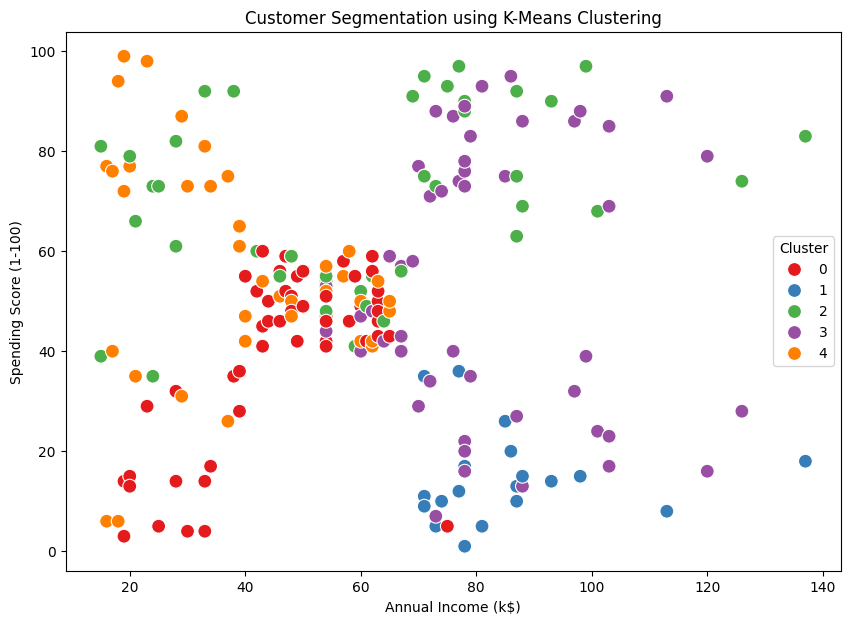

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100,
    data=df
)

plt.title("Customer Segmentation using K-Means Clustering")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend(title="Cluster")

plt.show()

### Observation

- The K-Means algorithm successfully divided customers into five distinct clusters.
- Customers in the same cluster have similar purchasing behavior.
- The visualization clearly shows different customer groups based on annual income and spending score.
- These customer segments can help businesses target different groups with personalized marketing strategies.

# Cluster Analysis

The average values of Age, Annual Income, and Spending Score are calculated for each cluster to understand the characteristics of each customer segment.

In [ ]:
cluster_summary = df.groupby('Cluster').mean()

cluster_summary

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.490196,56.470588,46.098039,39.313725
1,0.000000,39.500000,85.150000,14.050000
2,0.000000,28.690476,60.904762,70.238095
3,1.000000,37.897959,82.122449,54.448980
4,1.000000,27.315789,38.842105,56.210526


# Cluster Interpretation

### Cluster 0
- Medium annual income
- Low spending score
- Customers spend less despite having moderate income.

### Cluster 1
- High annual income
- Very low spending score
- These customers have strong purchasing power but spend cautiously.

### Cluster 2
- Medium annual income
- High spending score
- These customers are active shoppers and are valuable for marketing campaigns.

### Cluster 3
- High annual income
- Moderate spending score
- These customers have high income and moderate purchasing behavior.

### Cluster 4
- Low annual income
- Moderate spending score
- These customers have limited income but still show moderate purchasing activity.

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,51
1,20
2,42
3,49
4,38


### Observation

The above table shows the number of customers present in each cluster. This helps us understand the distribution of customers among different segments.

# Cluster Centers

Cluster centers represent the average position of customers within each cluster after training the K-Means model.

In [ ]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.470588,46.098039,39.313725
1,39.500000,85.150000,14.050000
2,28.690476,60.904762,70.238095
3,37.897959,82.122449,54.448980
4,27.315789,38.842105,56.210526


### Observation

The chart shows the distribution of customers across the five clusters. Some clusters contain more customers than others, indicating that certain customer behaviors are more common.

# Business Insights

Based on the customer segments obtained through K-Means clustering:

- Customers with high spending scores can be targeted with loyalty programs and premium offers.
- High-income customers with low spending can be encouraged through personalized discounts and promotional campaigns.
- Moderate-income customers with high spending are valuable customers and should be retained.
- Businesses can design different marketing strategies for each customer segment instead of using a single strategy for everyone.

# Conclusion

In this project, K-Means clustering was successfully applied to segment customers based on their demographic and purchasing behavior.

The Elbow Method was used to determine the optimal number of clusters, and five customer groups were identified.

Customer segmentation helps businesses better understand customer behavior, improve marketing strategies, increase customer satisfaction, and optimize business decisions.

In [ ]:
import pickle

In [ ]:
with open("kmeans_model.pkl","wb") as file:
    pickle.dump(kmeans,file)

In [ ]:
with open("scaler.pkl","wb") as file:
    pickle.dump(scaler,file)

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 108.2 MB/s eta 0:00:00
